In [1]:
# Import the libraries needed for data analysis and visualisation
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

In [2]:
# Load the SAT results dataset from the CSV file
# The CSV file must be in the same folder as this Jupyter Notebook

df = pd.read_csv("2012_SAT_Results.csv")
# Display the first 5 rows of the dataset
# This helps us check that the data was loaded correctly
df.head()

,DBN,SCHOOL NAME,Num of SAT Test Takers,SAT Critical Reading Avg. Score,SAT Math Avg. Score,SAT Writing Avg. Score
0,01M292,HENRY STREET SCHOOL FOR INTERNATIONAL STUDIES,29,355,404,363
1,01M448,UNIVERSITY NEIGHBORHOOD HIGH SCHOOL,91,383,423,366
2,01M450,EAST SIDE COMMUNITY SCHOOL,70,377,402,370
3,01M458,FORSYTH SATELLITE ACADEMY,7,414,401,359
4,01M509,MARTA VALLE HIGH SCHOOL,44,390,433,384


In [3]:
# Check the structure of the dataset
# This shows the number of rows, column types, and missing values

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 478 entries, 0 to 477
Data columns (total 6 columns):
 #   Column                           Non-Null Count  Dtype 
---  ------                           --------------  ----- 
 0   DBN                              478 non-null    object
 1   SCHOOL NAME                      478 non-null    object
 2   Num of SAT Test Takers           478 non-null    object
 3   SAT Critical Reading Avg. Score  478 non-null    object
 4   SAT Math Avg. Score              478 non-null    object
 5   SAT Writing Avg. Score           478 non-null    object
dtypes: object(6)
memory usage: 22.5+ KB


In [4]:
# Define the columns that should contain numeric values (scores and number of students)
score_columns = [
    "Num of SAT Test Takers",
    "SAT Critical Reading Avg. Score",
    "SAT Math Avg. Score",
    "SAT Writing Avg. Score"
]

# Replace 's' values with NaN (these represent missing data in the dataset)
df = df.replace("s", np.nan)

# Convert the selected columns from text (object) to numeric values
# If conversion fails, values will be set to NaN
for col in score_columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

In [5]:
# Check the dataset structure again after cleaning
# We want to confirm that numeric columns are now correctly formatted
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 478 entries, 0 to 477
Data columns (total 6 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   DBN                              478 non-null    object 
 1   SCHOOL NAME                      478 non-null    object 
 2   Num of SAT Test Takers           421 non-null    float64
 3   SAT Critical Reading Avg. Score  421 non-null    float64
 4   SAT Math Avg. Score              421 non-null    float64
 5   SAT Writing Avg. Score           421 non-null    float64
dtypes: float64(4), object(2)
memory usage: 22.5+ KB


In [6]:
# Remove rows that contain missing values in important columns
df_clean = df.dropna(subset=score_columns).copy()

# Check the new shape of the dataset
df_clean.shape

(421, 6)

In [7]:
# Create a total SAT score (sum of all three subjects)
df_clean["Total_SAT"] = (
    df_clean["SAT Critical Reading Avg. Score"] +
    df_clean["SAT Math Avg. Score"] +
    df_clean["SAT Writing Avg. Score"]
)

# Create an average SAT score
df_clean["Average_SAT"] = df_clean["Total_SAT"] / 3

# Check results
df_clean.head()

,DBN,SCHOOL NAME,Num of SAT Test Takers,SAT Critical Reading Avg. Score,SAT Math Avg. Score,SAT Writing Avg. Score,Total_SAT,Average_SAT
0,01M292,HENRY STREET SCHOOL FOR INTERNATIONAL STUDIES,29.0,355.0,404.0,363.0,1122.0,374.000000
1,01M448,UNIVERSITY NEIGHBORHOOD HIGH SCHOOL,91.0,383.0,423.0,366.0,1172.0,390.666667
2,01M450,EAST SIDE COMMUNITY SCHOOL,70.0,377.0,402.0,370.0,1149.0,383.000000
3,01M458,FORSYTH SATELLITE ACADEMY,7.0,414.0,401.0,359.0,1174.0,391.333333
4,01M509,MARTA VALLE HIGH SCHOOL,44.0,390.0,433.0,384.0,1207.0,402.333333


In [8]:
# Show descriptive statistics for school size and SAT performance
df_clean[
    [
        "Num of SAT Test Takers",
        "Total_SAT",
        "Average_SAT"
    ]
].describe()

,Num of SAT Test Takers,Total_SAT,Average_SAT
count,421.000000,421.000000,421.000000
mean,110.320665,1208.204276,402.734759
std,155.534254,174.536123,58.178708
min,6.000000,887.000000,295.666667
25%,41.000000,1102.000000,367.333333
50%,62.000000,1169.000000,389.666667
75%,95.000000,1257.000000,419.000000
max,1277.000000,2096.000000,698.666667


In [9]:
# Count how many schools are above and below the average SAT score

overall_avg = df_clean["Total_SAT"].mean()

above_avg = (df_clean["Total_SAT"] > overall_avg).sum()
below_avg = (df_clean["Total_SAT"] <= overall_avg).sum()

print("Above average schools:", above_avg)
print("Below average schools:", below_avg)

Above average schools: 145
Below average schools: 276


In [10]:
# Define threshold for school size (use median)
median_students = df_clean["Num of SAT Test Takers"].median()

small_schools = (df_clean["Num of SAT Test Takers"] <= median_students).sum()
large_schools = (df_clean["Num of SAT Test Takers"] > median_students).sum()

print("Small schools:", small_schools)
print("Large schools:", large_schools)

Small schools: 213
Large schools: 208


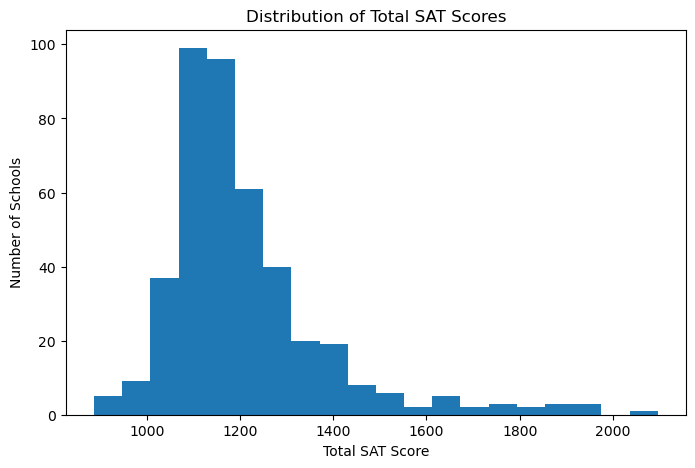

In [11]:
# Plot histogram of Total SAT scores
plt.figure(figsize=(8,5))
plt.hist(df_clean["Total_SAT"], bins=20)

plt.title("Distribution of Total SAT Scores")
plt.xlabel("Total SAT Score")
plt.ylabel("Number of Schools")

plt.show()


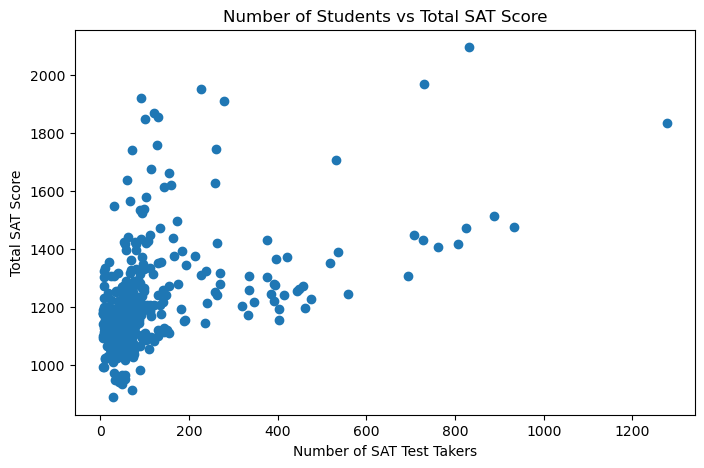

In [12]:
# Scatter plot: Number of students vs Total SAT score
plt.figure(figsize=(8,5))
plt.scatter(df_clean["Num of SAT Test Takers"], df_clean["Total_SAT"])

plt.title("Number of Students vs Total SAT Score")
plt.xlabel("Number of SAT Test Takers")
plt.ylabel("Total SAT Score")

plt.show()

In [13]:
# Select only the score columns for PCA
features = [
    "SAT Critical Reading Avg. Score",
    "SAT Math Avg. Score",
    "SAT Writing Avg. Score"
]

X = df_clean[features]

In [14]:
# Standardize the data so all features have equal importance
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [15]:
# Apply PCA to reduce from 3 dimensions to 2
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

In [16]:
# Add PCA components to the dataset
df_clean["PC1"] = X_pca[:, 0]
df_clean["PC2"] = X_pca[:, 1]

# Check results
df_clean.head()

,DBN,SCHOOL NAME,Num of SAT Test Takers,SAT Critical Reading Avg. Score,SAT Math Avg. Score,SAT Writing Avg. Score,Total_SAT,Average_SAT,PC1,PC2
0,01M292,HENRY STREET SCHOOL FOR INTERNATIONAL STUDIES,29.0,355.0,404.0,363.0,1122.0,374.000000,-0.861978,0.428167
1,01M448,UNIVERSITY NEIGHBORHOOD HIGH SCHOOL,91.0,383.0,423.0,366.0,1172.0,390.666667,-0.378741,0.429058
2,01M450,EAST SIDE COMMUNITY SCHOOL,70.0,377.0,402.0,370.0,1149.0,383.000000,-0.583753,0.186056
3,01M458,FORSYTH SATELLITE ACADEMY,7.0,414.0,401.0,359.0,1174.0,391.333333,-0.322800,-0.057691
4,01M509,MARTA VALLE HIGH SCHOOL,44.0,390.0,433.0,384.0,1207.0,402.333333,-0.039659,0.395156


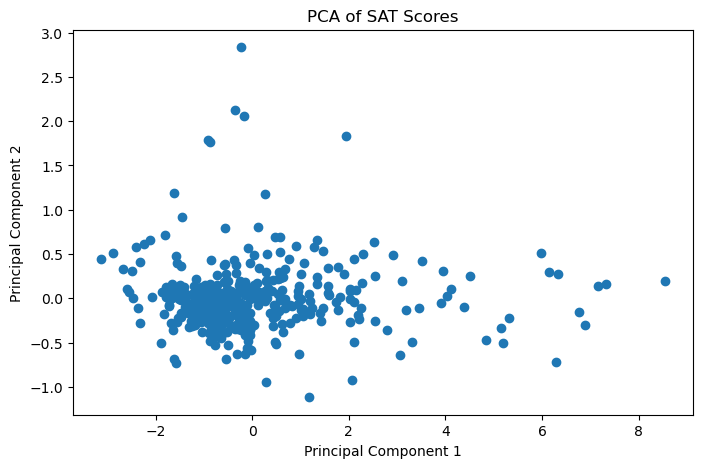

In [17]:
# Scatter plot of PCA results
plt.figure(figsize=(8,5))
plt.scatter(df_clean["PC1"], df_clean["PC2"])

plt.title("PCA of SAT Scores")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.show()

In [18]:
# Apply KMeans clustering
kmeans = KMeans(n_clusters=3, random_state=42)

df_clean["Cluster"] = kmeans.fit_predict(X_pca)

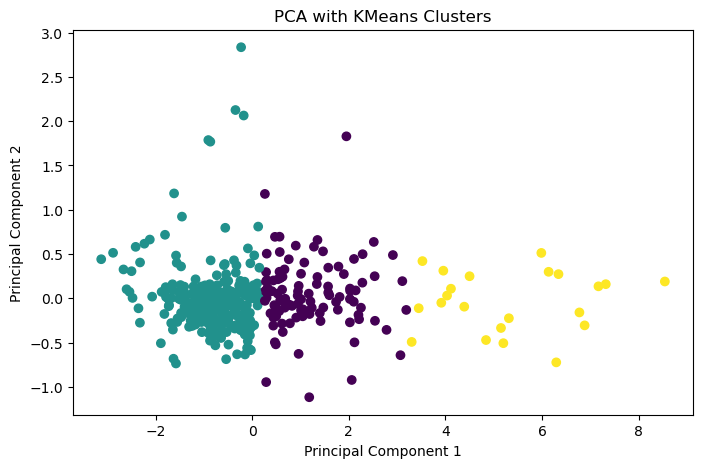

In [19]:
# Plot PCA with clusters
plt.figure(figsize=(8,5))

plt.scatter(
    df_clean["PC1"],
    df_clean["PC2"],
    c=df_clean["Cluster"]
)

plt.title("PCA with KMeans Clusters")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.show()

In [20]:
# CELL 18 — Summarise each cluster

cluster_summary = df_clean.groupby("Cluster")[
    [
        "Num of SAT Test Takers",
        "SAT Critical Reading Avg. Score",
        "SAT Math Avg. Score",
        "SAT Writing Avg. Score",
        "Total_SAT",
        "Average_SAT"
    ]
].mean()

cluster_summary

,Num of SAT Test Takers,SAT Critical Reading Avg. Score,SAT Math Avg. Score,SAT Writing Avg. Score,Total_SAT,Average_SAT
Cluster,,,,,,
0,200.500000,438.962264,458.462264,432.320755,1329.745283,443.248428
1,65.938567,373.979522,382.645051,366.150171,1122.774744,374.258248
2,266.909091,575.090909,605.272727,580.000000,1760.363636,586.787879


In [21]:
# CELL 19 — Count number of schools in each cluster

df_clean["Cluster"].value_counts()

Cluster
1    293
0    106
2     22
Name: count, dtype: int64

In [22]:
# Select features including both school size and SAT performance
features_extended = [
    "Num of SAT Test Takers",
    "SAT Critical Reading Avg. Score",
    "SAT Math Avg. Score",
    "SAT Writing Avg. Score"
]

X_extended = df_clean[features_extended]

In [23]:
# Standardize the extended features
# This is important because number of students and SAT scores have different scales
scaler_extended = StandardScaler()

X_extended_scaled = scaler_extended.fit_transform(X_extended)

In [24]:
# Apply PCA to reduce the four variables into two principal components
pca_extended = PCA(n_components=2)

X_pca_extended = pca_extended.fit_transform(X_extended_scaled)

In [25]:
# Add the extended PCA components to the dataset
df_clean["PC1_extended"] = X_pca_extended[:, 0]
df_clean["PC2_extended"] = X_pca_extended[:, 1]

# Check the new columns
df_clean.head()

,DBN,SCHOOL NAME,Num of SAT Test Takers,SAT Critical Reading Avg. Score,SAT Math Avg. Score,SAT Writing Avg. Score,Total_SAT,Average_SAT,PC1,PC2,Cluster,PC1_extended,PC2_extended
0,01M292,HENRY STREET SCHOOL FOR INTERNATIONAL STUDIES,29.0,355.0,404.0,363.0,1122.0,374.000000,-0.861978,0.428167,1,-0.986639,-0.113882
1,01M448,UNIVERSITY NEIGHBORHOOD HIGH SCHOOL,91.0,383.0,423.0,366.0,1172.0,390.666667,-0.378741,0.429058,1,-0.393645,0.081966
2,01M450,EAST SIDE COMMUNITY SCHOOL,70.0,377.0,402.0,370.0,1149.0,383.000000,-0.583753,0.186056,1,-0.635773,-0.006299
3,01M458,FORSYTH SATELLITE ACADEMY,7.0,414.0,401.0,359.0,1174.0,391.333333,-0.322800,-0.057691,1,-0.538521,-0.515145
4,01M509,MARTA VALLE HIGH SCHOOL,44.0,390.0,433.0,384.0,1207.0,402.333333,-0.039659,0.395156,1,-0.183990,-0.320617


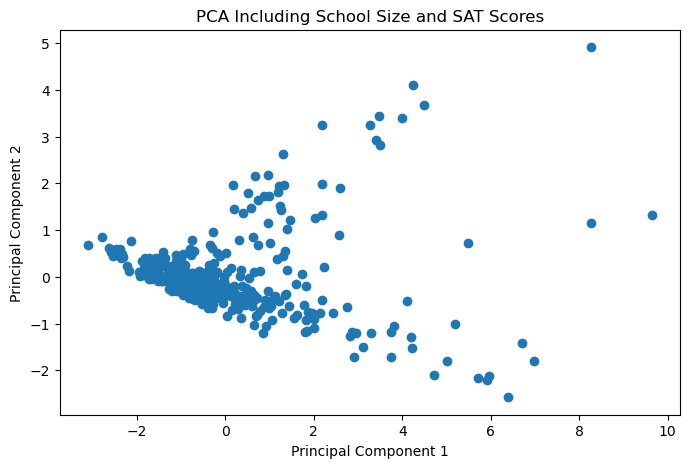

In [26]:
# Plot the PCA results including school size and SAT scores
plt.figure(figsize=(8, 5))

plt.scatter(
    df_clean["PC1_extended"],
    df_clean["PC2_extended"]
)

plt.title("PCA Including School Size and SAT Scores")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.show()

In [27]:
# Apply KMeans clustering to the extended PCA results
kmeans_extended = KMeans(n_clusters=3, random_state=42, n_init=10)

df_clean["Cluster_extended"] = kmeans_extended.fit_predict(X_pca_extended)

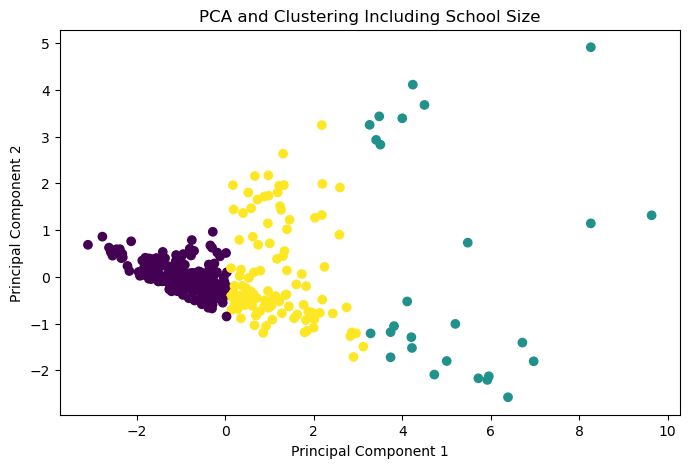

In [28]:
# Plot the extended PCA results with cluster colours
plt.figure(figsize=(8, 5))

plt.scatter(
    df_clean["PC1_extended"],
    df_clean["PC2_extended"],
    c=df_clean["Cluster_extended"]
)

plt.title("PCA and Clustering Including School Size")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.show()

In [29]:
# Summarise each cluster using the original variables
cluster_extended_summary = df_clean.groupby("Cluster_extended")[
    [
        "Num of SAT Test Takers",
        "SAT Critical Reading Avg. Score",
        "SAT Math Avg. Score",
        "SAT Writing Avg. Score",
        "Total_SAT",
        "Average_SAT"
    ]
].mean()

cluster_extended_summary

,Num of SAT Test Takers,SAT Critical Reading Avg. Score,SAT Math Avg. Score,SAT Writing Avg. Score,Total_SAT,Average_SAT
Cluster_extended,,,,,,
0,55.665493,373.549296,381.292254,365.591549,1120.433099,373.477700
1,423.185185,551.185185,588.148148,556.296296,1695.629630,565.209877
2,174.636364,434.436364,453.281818,427.454545,1315.172727,438.390909


In [30]:
# Count how many schools belong to each extended cluster
df_clean["Cluster_extended"].value_counts()

Cluster_extended
0    284
2    110
1     27
Name: count, dtype: int64

In [31]:
# CELL 29 — Evaluate clustering quality

from sklearn.metrics import silhouette_score

# Calculate silhouette score using PCA data and cluster labels
score = silhouette_score(X_pca_extended, df_clean["Cluster_extended"])

print("Silhouette Score:", score)

Silhouette Score: 0.5152657344228798
